## Python deep learning (DL) framework for vehicle detection and deep dive of Tesla autopilot accidents

In [ ]:
"""
This project is one of the Microsoft AI Engineering Capstone projects under Microsoft AI Engineer Program assigned by Simplilearn (www.simplilearn.com).
I completed this program with accomplishing this project. 

"""

In [ ]:
"""
I used the anaconda environment (anaconda prompt) with making a new environment (Python [conda env.tf_env2]) in this project. All data science 
libraries were installed in this environment. This environment connected to jupyter notebook to run this project. 

"""

In [ ]:
"""
# Project title:
Automatic vehicle detection using deep learning (computer vision) and Tesla autopilot accident analysis

# Project background:
With the accelerated development of autonomous driving systems, detection accuracy for vehicles and awareness for real-world traffic accident patterns
are significant. This project leverages a combination of (1) a Python deep learning associated with object detection computer vision model to pinpoint
vehicles in images, and (2) a statistical analysis of Tesla crash data to examine fatal crash cases and autopilot-related incidents.
For AI supported transportation systems, coupling of computer vision with real-world data analysis supports both application development and 
practical findings.

# Project objective:
•	Construct a convolutional neural network (CNN) model for vehicle detection and bounding box prediction.
•	With labeled image data, train and then evaluate the model.
•	Analyze the Tesla accident dataset using end-to-end Exploratory Data Analysis (EDA) approaches.
•	Research on driver behavior including death trends and some risks factors involved in autopilot.
•	Examine accident trends by uncovering key findings from dataset

# Core technologies:
•	Jupyter notebook (Python) | NumPy | Pandas | Matplotlib | Seaborn | TensorFlow (Keras) |  Scikit-learn. 

# Project elements:
Project # 1: Vehicle detection using CNN deep approach
•	Dataset preparation: normalization of pixel values | bounding box resizing | conversion of class labels into one-hot vectors 
•	Develop a deep learning CNN model with two outputs [vehicle localization (regression for bounding box) and classification]
•	Training the model: Train-test split including validation with batch training
•	Model evaluation criteria: Accuracy | loss (bounding box and classification) 

Project # 2: Tesla accident data analysis used for Data Science
•	Dataset cleansing process: dropped duplicate rows | addressed missing values | converted categorical data into numerical values
•	Exploratory Data Analysis (EDA) applied for: accident distribution by year, date, state, and country | analysis of deaths per accident |
    Tesla driver and passenger death cases | cyclist and pedestrian participation in accidents | Tesla collision frequency with other vehicles |
    distribution of accidents across Tesla models | confirmed distribution of autopilot deaths, and high performing in bounding box predictions
    
# Results:
With a CNN model:
•	trained an object detection model with obtaining reliable results
•	accuracy (about 100%) in classification task
•	Strong in bounding box predictions
•	Model correctly classified vehicles in the dataset (images).

# Data analysis outcomes:
•	One death in most crashes                                                                                                              
•	In Tesla occupant deaths, about 16% of accidents  
•	Frequency of higher accidents observed in some Tesla models
•	Autopilot deaths confirmed as accurate deaths are not frequent.

# Model output:
•	Training loss obtained from bounding box is about 0.64. 
•	Model with unseen image dataset works well. 
•	Accuracy involved for image classification is 100%.
•	Test dataset with CNN model works well.

# Project conclusion:
End-to-end AI workflow is clearly shown in this project. It has 
•	CNN Model: Recognizes vehicles in images dataset with high precision and appropriate for self-driving applications.
•	Data science analysis: Gathers primary accident patterns over time engaging Tesla vehicles, increase consciousness of safety issues for drivers, 
    pedestrians, and occupants
    
The combination of computer vision (deep learning) and real-world data analytics helps open valuable patterns in AI safety and transportation 
applications.

# Project file:
capstone__one_automatic_detection_of_vehicles_deep_learning_framework_analyze_usage_autopilot.ipynb

"""

In [45]:
import os

#### Set a path for vehicle images dataset

In [48]:
images_autonomous_vehicles_folder= r"C:\Users\gobin\Documents\python_ml_dl_project_one\Images"

### Prepare the dataset for model training

In [51]:
# Extract image file formats from vehicle dataset folder

dataset_image_types = set()
dataset_image_files = [] 

for image_file in os.listdir(images_autonomous_vehicles_folder):
    image_extension = os.path.splitext(image_file)[1].lower()
    
    # ignore files without a file extension (e.g., ignore files that are not '.jpg', '.jpeg', '.png')
    if image_extension in ['.jpg', '.jpeg', '.png']:
        dataset_image_types.add(image_extension)
        dataset_image_files.append(image_file)

print('Collected image types from dataset:', dataset_image_types)

print()

print(f' {len(dataset_image_files)} images in the dataset')

Collected image types from dataset: {'.jpg'}

 5626 images in the dataset


In [54]:
images = [i for i in os.listdir(images_autonomous_vehicles_folder) if i.endswith(('.png', '.jpg', '.jpeg'))]
print(f' Collected images: {len(images)}')

 Collected images: 5626


#### Some sample images from vehicle dataset

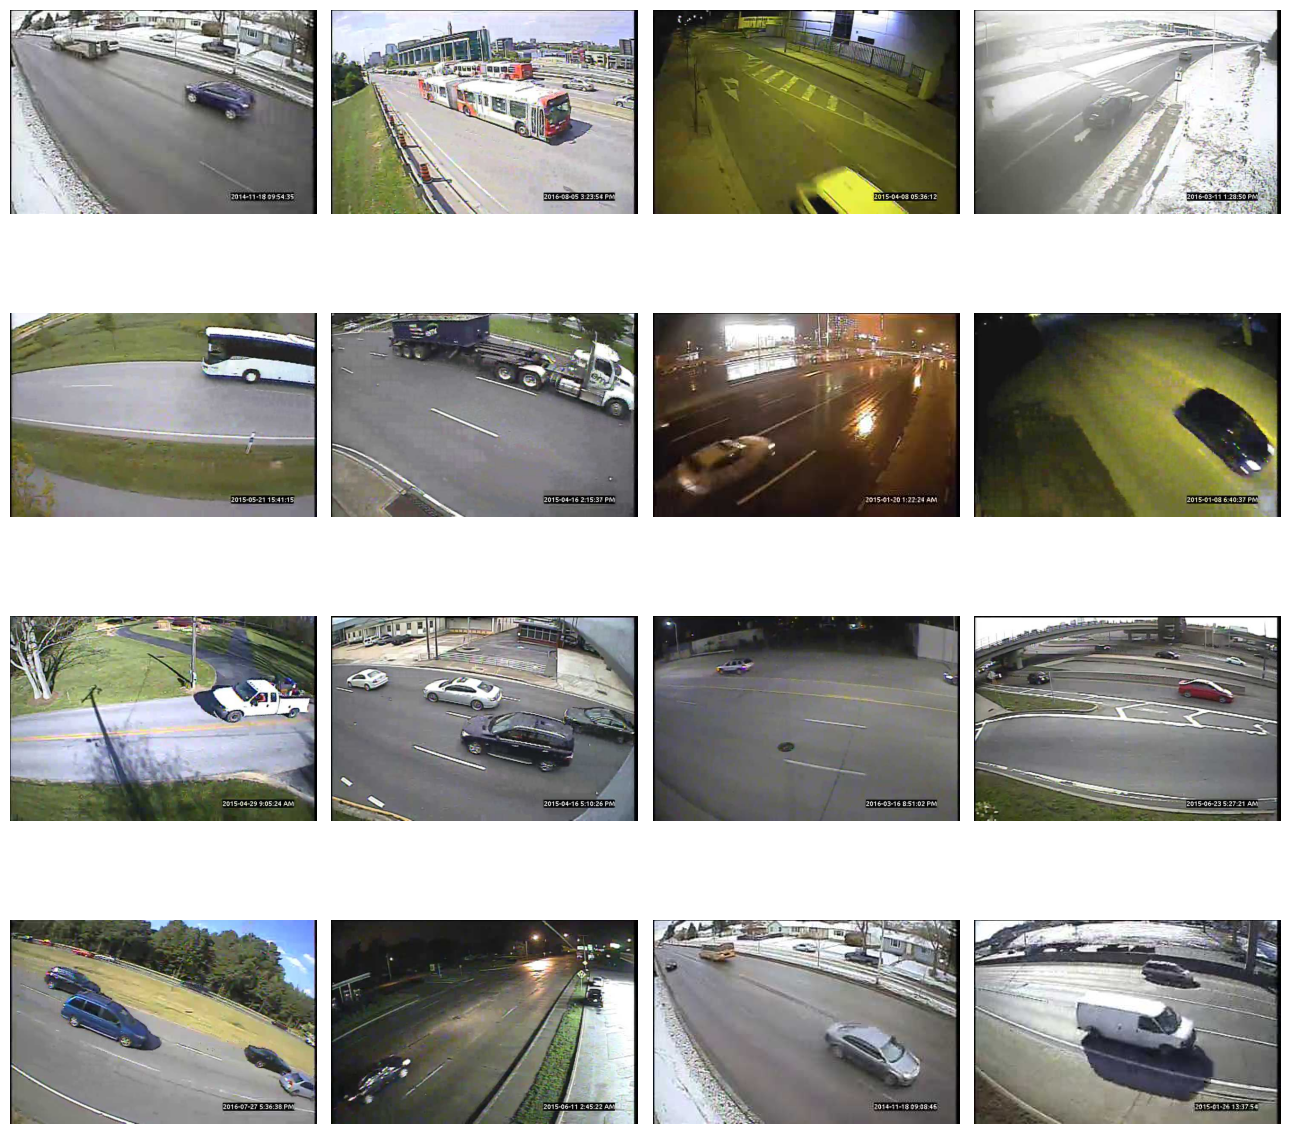

In [23]:
from PIL import Image
import matplotlib.pyplot as plt

# preview first 16 images

plt.figure(figsize = (13, 13))
for image_index, image_name  in enumerate(dataset_image_files[:16]):
    full_image_path = os.path.join(images_autonomous_vehicles_folder, image_name)
    loaded_image = Image.open(full_image_path)
    
    plt.subplot(4, 4, image_index + 1)
    plt.imshow(loaded_image)
    plt.axis('off')

plt.tight_layout()
plt.show()

### Image preprocessing for Convolutional Neural Network (CNN)

In [70]:
# Resize vehicle images to 224 x 224 and convert to Numpy arrays for CNN Input

import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array

image_width = 224
image_height = 224

# Load all images into a list
dataset_images = []

for image_filename in images:
    image_location = os.path.join(images_autonomous_vehicles_folder, image_filename)
    loaded_image = load_img(image_location, target_size=(image_width, image_height), color_mode = 'rgb')
    image_array = img_to_array(loaded_image)
    dataset_images.append(image_array)


# list at numpy array
dataset_images = np.array(dataset_images, dtype = 'float32')
print(f'Dimensions of image dataset: {dataset_images.shape}')


# Do normalization
dataset_images = dataset_images / 255.0

print(f'Dimensions of image dataset: {dataset_images.shape}')

print()

print(dataset_images.min(), dataset_images.max())

Dimensions of image dataset: (5626, 224, 224, 3)
Dimensions of image dataset: (5626, 224, 224, 3)

0.0 1.0


### Load labels.csv file and see column names

In [26]:
import pandas as pd

labels_csv_file_path = r'C:\Users\gobin\Documents\python_ml_dl_project_one\labels.csv'

labels_data = pd.read_csv(labels_csv_file_path)

print(labels_data.head(4))
print()
print('Column names in labels_csv file:', labels_data.columns.tolist())

   00000000       pickup_truck  213  34  255   50
0         0                car  194  78  273  122
1         0                car  155  27  183   35
2         0  articulated_truck   43  25  109   55
3         0                car  106  32  124   45

Column names in labels_csv file: ['00000000', 'pickup_truck', '213', '34', '255', '50']


#### Read labels.csv and give column names

In [30]:
# Read labels.csv and give column names

column_names = ['image_id', 'vehicle_type', 'x_start', 'y_start', 'x_end', 'y_end']

labels_data = pd.read_csv(labels_csv_file_path,
                          names = column_names,
                          header = None
                         )

print(labels_data.head())
print()
print('\nColumn names in labels CSV file:', labels_data.columns.tolist())

   image_id       vehicle_type  x_start  y_start  x_end  y_end
0         0       pickup_truck      213       34    255     50
1         0                car      194       78    273    122
2         0                car      155       27    183     35
3         0  articulated_truck       43       25    109     55
4         0                car      106       32    124     45


Column names in labels CSV file: ['image_id', 'vehicle_type', 'x_start', 'y_start', 'x_end', 'y_end']


#### See vehicle_classes in CSV file

In [33]:
vehicle_classes = labels_data['vehicle_type'].unique()
print('vehicle_classes in CSV file:', vehicle_classes)

print()

# vehicle class mapping
vehicle_class_mapping = {class_name: i for i, class_name in enumerate(vehicle_classes)}
print(' vehicle class mapping:', vehicle_class_mapping)

vehicle_classes in CSV file: <StringArray>
[         'pickup_truck',                   'car',     'articulated_truck',
                   'bus',     'motorized_vehicle',              'work_van',
     'single_unit_truck',            'pedestrian',               'bicycle',
 'non-motorized_vehicle',            'motorcycle']
Length: 11, dtype: str

 vehicle class mapping: {'pickup_truck': 0, 'car': 1, 'articulated_truck': 2, 'bus': 3, 'motorized_vehicle': 4, 'work_van': 5, 'single_unit_truck': 6, 'pedestrian': 7, 'bicycle': 8, 'non-motorized_vehicle': 9, 'motorcycle': 10}


### Create bounding box coordinates and class labels

In [74]:
bbox_list_per_image = []
class_list_per_image = []

for image_file in dataset_image_files:
    image_idx = int(os.path.splitext(image_file)[0])
    
    image_label = labels_data[labels_data['image_id'] == image_idx]
    
    if not image_label.empty:
        # Rescale bounding box values using image dimensions
        x_start = image_label['x_start'].values[0] / image_width
        y_start = image_label['y_start'].values[0] / image_height
        x_end = image_label['x_end'].values[0] / image_width
        y_end = image_label['y_end'].values[0] / image_height
        bbox_list_per_image.append([x_start, y_start, x_end, y_end])
 
        # Convert vehicle type to integer id
        vehicle_type_id = vehicle_class_mapping[row['vehicle_type'].values[0]]
        class_list_per_image.append(vehicle_type_id)

from tensorflow.keras.utils import to_categorical

bounding_boxes_array = np.array(bbox_list_per_image, dtype='float32')
class_targets = to_categorical(class_list_per_image, num_classes=len(vehicle_class_mapping))

print(f'Bounding boxes array: {bounding_boxes_array.shape}')
print(f'Class targets : {class_targets.shape}')

Bounding boxes array: (5626, 4)
Class targets : (5626, 11)


### Make training and test dataset for CNN workflow

In [77]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_bbox_train, y_bbox_test, y_class_train, y_class_test = train_test_split(dataset_images,
                                                                                           bounding_boxes_array,
                                                                                           class_targets,
                                                                                           test_size = 0.2,
                                                                                           random_state = 42
                                                                                          )

print("Train dataset:", X_train.shape[0])
print("Test dataset:", X_test.shape[0])

Train dataset: 4500
Test dataset: 1126


### Make CNN model for vehicle classification, and bounding box

In [81]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Number of vehicle classes
number_of_classes = len(vehicle_class_mapping)  # 11


# Max objects to detect per image
#max_objects_per_image = 5

# Define CNN input shape
input_layer = Input(shape = (224, 224, 3))

# Get image features using convolutional and pooling layers
# c: conv_layer_output

c = Conv2D(32, (3, 3), activation='relu', padding='same')(input_layer)
c = MaxPooling2D((2, 2))(c)

c = Conv2D(64, (3, 3), activation='relu', padding='same')(c)
c = MaxPooling2D((2, 2))(c)

c = Conv2D(128, (3, 3), activation='relu', padding='same')(c)
c = MaxPooling2D((2, 2))(c)

# Flatten features 
c = Flatten()(c)

# Apply dense layer and dropout to get features
c = Dense(256, activation = 'relu')(c)
c = Dropout(0.4)(c)

# Output layer for predicting bounding box coordinates (max_objects_per_image * 5)
bounding_box_output = Dense(4, activation = 'sigmoid', name = 'bounding_box_output')(c)

# Output layer for predicting class probabilities for each object using softmax
predicted_classes = Dense(number_of_classes, activation='softmax', name = 'predicted_classes')(c)

# Define the CNN model with bounding box and predicted classes
object_detection_model = Model(inputs = input_layer, outputs = [bounding_box_output, predicted_classes])

# Compile the CNN model for training
object_detection_model.compile(optimizer = 'adam',
                               loss = {'bounding_box_output':'mse', 'predicted_classes':'categorical_crossentropy'},
                               metrics = {'predicted_classes':'accuracy'})

object_detection_model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 224, 224, 32)         896       ['input_1[0][0]']             
                                                                                                  
 max_pooling2d (MaxPooling2  (None, 112, 112, 32)         0         ['conv2d[0][0]']              
 D)                                                                                               
                                                                                                  
 conv2d_1 (Conv2D)           (None, 112, 112, 64)         18496     ['max_pooling2d[0][0]']   

### Training the CNN supported vehicle detection model

In [85]:

history = object_detection_model.fit(X_train,
                                     {'bounding_box_output': bounding_boxes_array, 'predicted_classes': class_targets},
                                     validation_split = 0.2,
                                     epochs = 20,
                                     batch_size = 32
                                    )

Epoch 1/20
113/113 [==============================] - 370s 3s/step - loss: 0.6637 - bounding_box_output_loss: 0.6633 - predicted_classes_loss: 4.1379e-04 - predicted_classes_accuracy: 1.0000 - val_loss: 0.6282 - val_bounding_box_output_loss: 0.6282 - val_predicted_classes_loss: 2.8152e-06 - val_predicted_classes_accuracy: 1.0000
Epoch 2/20
113/113 [==============================] - 365s 3s/step - loss: 0.6527 - bounding_box_output_loss: 0.6525 - predicted_classes_loss: 1.4457e-04 - predicted_classes_accuracy: 1.0000 - val_loss: 0.6254 - val_bounding_box_output_loss: 0.6254 - val_predicted_classes_loss: 4.8617e-06 - val_predicted_classes_accuracy: 1.0000
Epoch 3/20
113/113 [==============================] - 440s 4s/step - loss: 0.6524 - bounding_box_output_loss: 0.6523 - predicted_classes_loss: 1.4238e-04 - predicted_classes_accuracy: 1.0000 - val_loss: 0.6260 - val_bounding_box_output_loss: 0.6260 - val_predicted_classes_loss: 4.4677e-07 - val_predicted_classes_accuracy: 1.0000
Epoch 4

#### CNN model evaluation metrics including classification and bounding box loss

In [117]:
# Classification
train_accuracy = history.history['predicted_classes_accuracy']
print(f'Train classification accuracy: {train_accuracy[-1]:.3f}')

validation_accuracy = history.history['val_predicted_classes_accuracy']
print(f'Validation classification accuracy: {validation_accuracy[-1]:.3f}\n')


# Loss
training_loss = history.history['loss']
print(f'Training loss: {training_loss[-1]:.3f}')

validation_loss = history.history['val_loss']
print(f'Validation loss: {validation_loss[-1]:.3f}\n')


train_bounding_box_loss = history.history['bounding_box_output_loss']
print(f'Train bounding box loss: {train_bounding_box_loss[-1]:.3f}')

validation_bounding_box_loss = history.history['val_bounding_box_output_loss']
print(f'Validation bounding box loss: {validation_bounding_box_loss[-1]:.3f}')



Train classification accuracy: 1.000
Validation classification accuracy: 1.000

Training loss: 0.633
Validation loss: 0.633

Train bounding box loss: 0.633
Validation bounding box loss: 0.633


#### Training and validation accuracy across epochs

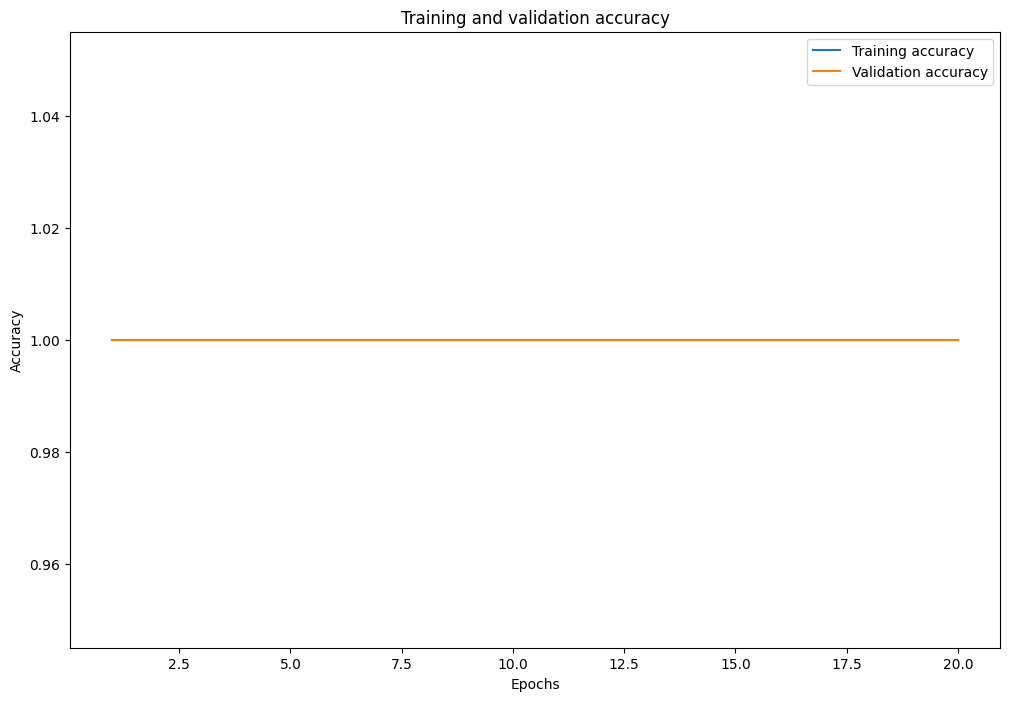

In [113]:
epochs = 20
epoch_indices = range(1, epochs + 1)

plt.figure(figsize=(12, 8))
plt.plot(epoch_indices, train_accuracy, label='Training accuracy')
plt.plot(epoch_indices, validation_accuracy, label='Validation accuracy')
plt.legend(loc='upper right')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

#### Training and validation loss by epochs

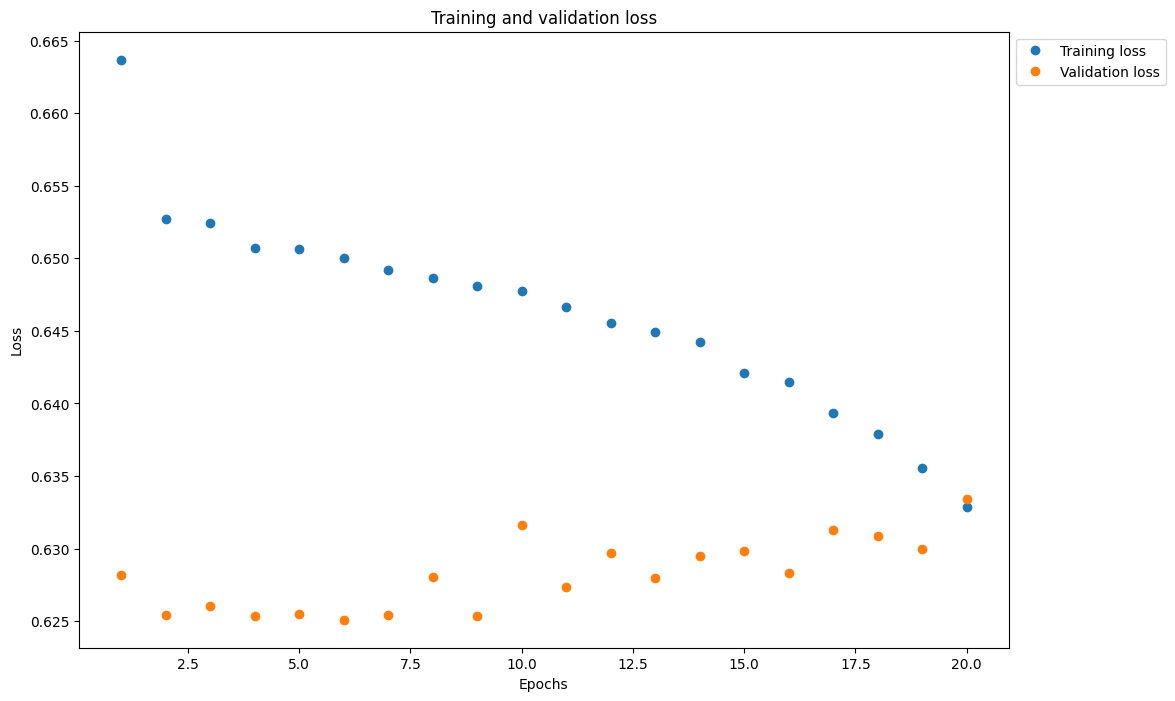

In [115]:
plt.figure(figsize = (12, 8))
plt.plot(epoch_indices, training_loss, marker = 'o', linestyle = 'None', label = 'Training loss')
plt.plot(epoch_indices, validation_loss, marker = 'o', linestyle = 'None', label = 'Validation loss')

plt.legend(loc = 'upper left', bbox_to_anchor = (1, 1))
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

#### Bounding box loss for training and validation by epochs

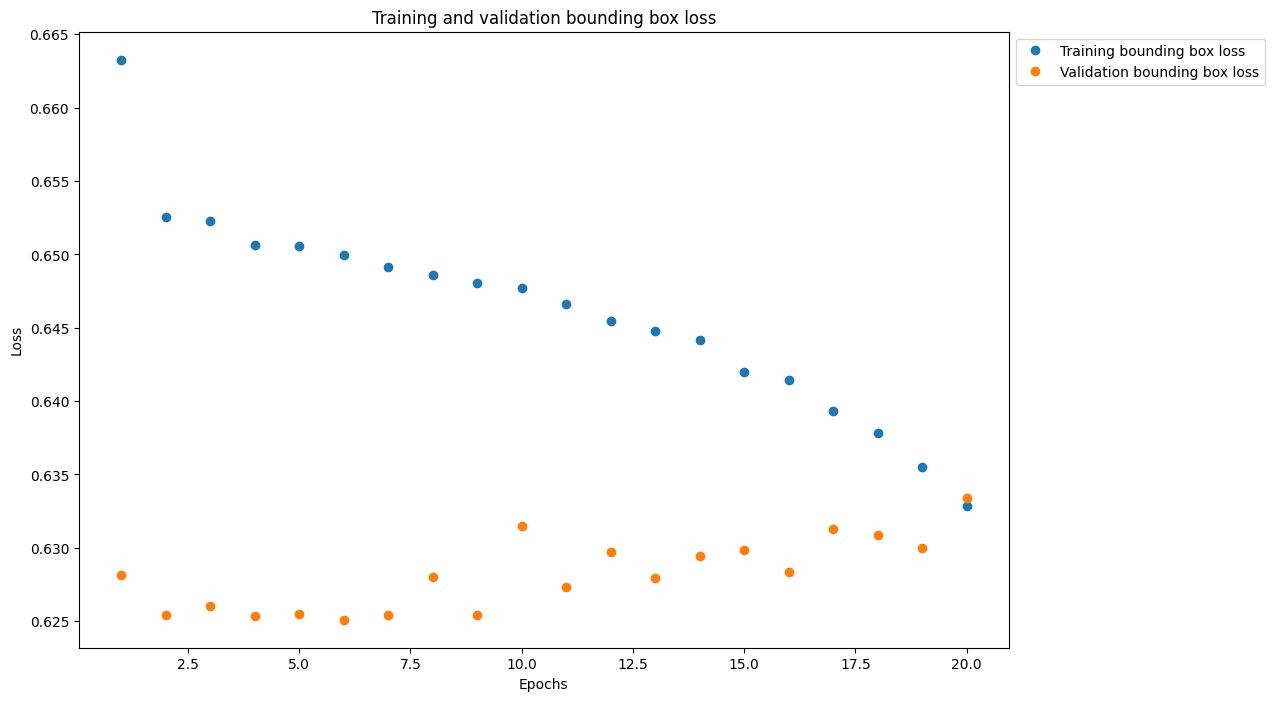

In [119]:
plt.figure(figsize=(12, 8))
plt.plot(epoch_indices, train_bounding_box_loss, marker = 'o', linestyle = 'None', label = 'Training bounding box loss')
plt.plot(epoch_indices, validation_bounding_box_loss, marker = 'o', linestyle = 'None', label = 'Validation bounding box loss')

plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.title('Training and validation bounding box loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

### Evaluate the model on test dataset

In [126]:
# Compute model performance metrics
total_loss, bbox_regression_loss, classification_loss, classification_accuracy = object_detection_model.evaluate(
    X_test, {'bounding_box_output': y_bbox_test, 'predicted_classes': y_class_test})

print()

print(f"bbox regression loss: {bbox_regression_loss:.4f}")
print(f"Classification loss: {classification_loss:.4f}")
print(f"Classification accuracy: {classification_accuracy:.4f}")

36/36 [==============================] - 14s 390ms/step - loss: 0.6404 - bounding_box_output_loss: 0.6404 - predicted_classes_loss: 3.8748e-08 - predicted_classes_accuracy: 1.0000

bbox regression loss: 0.6404
Classification loss: 0.0000
Classification accuracy: 1.0000


### Inference on a Sample Image

1/1 [==============================] - 0s 84ms/step


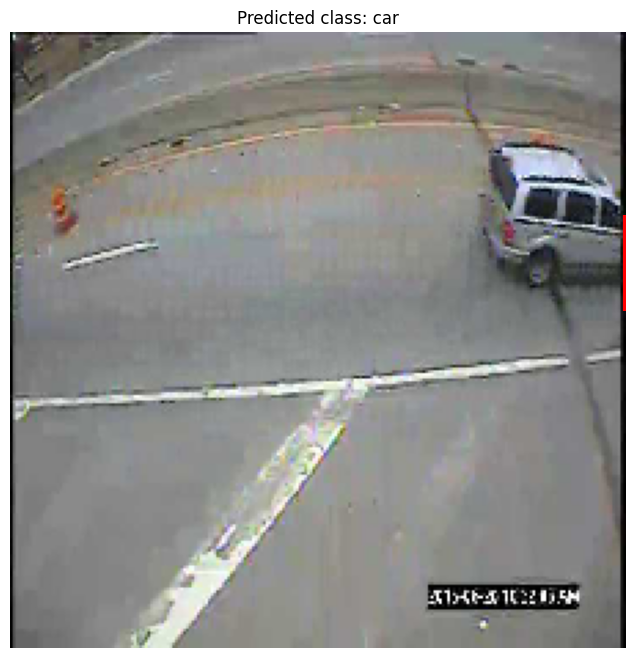

In [132]:
from matplotlib.patches import Rectangle

# Select a sample test image
test_image = X_test[0].reshape(1, 224, 224, 3)

# Run inference using your object detection model
bounding_box_prediction, predicted_class_probs = object_detection_model.predict(test_image)

# Map bounding box from [0,1] to pixel values
x_min = int(bounding_box_prediction[0][0] * 224)
y_min = int(bounding_box_prediction[0][1] * 224)
x_max = int(bounding_box_prediction[0][2] * 224)
y_max = int(bounding_box_prediction[0][3] * 224)

# Get predicted class index
predicted_class_idx = np.argmax(predicted_class_probs[0])

# Map index back to vehicle class name
predicted_class_name = list(vehicle_class_mapping.keys())[list(vehicle_class_mapping.values()).index(predicted_class_idx)]

# Plot image with bounding box and predicted class
plt.figure(figsize = (8, 8))
plt.imshow(X_test[0])
plt.gca().add_patch(Rectangle((x_min, y_min), x_max-x_min, y_max-y_min, edgecolor = 'red', facecolor='none', linewidth=3))
plt.title(f"Predicted class: {predicted_class_name}")
plt.axis('off')
plt.show()

In [ ]:

# Predicted the vehicle class (Car) is 100% (perfect)
"""
Note:

vehicle_classes in CSV file: <StringArray>
[         'pickup_truck',                   'car',     'articulated_truck',
                   'bus',     'motorized_vehicle',              'work_van',
     'single_unit_truck',            'pedestrian',               'bicycle',
 'non-motorized_vehicle',            'motorcycle']
Length: 11, dtype: str

 vehicle class mapping: {'pickup_truck': 0, 'car': 1, 'articulated_truck': 2, 'bus': 3, 'motorized_vehicle': 4, 'work_van': 5, 'single_unit_truck': 6, 'pedestrian': 7, 'bicycle': 8, 'non-motorized_vehicle': 9, 'motorcycle': 10}
"""

In [ ]:
"""
Second project:
Preliminary Data Inspection and Cleaning
a. Perform preliminary data inspection, checking for data types, missing values, and duplicates
b. Remove any columns that might not be relevant for the analysis
"""

In [134]:
tesla_deaths_data_path = r'C:\Users\gobin\Documents\python_ml_dl_project_one\Tesla - Deaths.csv'

tesla_data = pd.read_csv(tesla_deaths_data_path)
tesla_data.head(3)

,Case #,Year,Date,Country,State,Description,Deaths,Tesla driver,Tesla occupant,Other vehicle,...,Verified Tesla Autopilot Deaths,Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO,Unnamed: 16,Unnamed: 17,Source,Note,Deceased 1,Deceased 2,Deceased 3,Deceased 4
0,294.0,2022.0,1/17/2023,USA,CA,Tesla crashes into back of semi,1.0,1,-,-,...,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20230118162813/ht...,NaN,NaN,NaN,NaN,NaN
1,293.0,2022.0,1/7/2023,Canada,-,Tesla crashes,1.0,1,-,-,...,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20230109041434/ht...,NaN,Taren Singh Lal,NaN,NaN,NaN
2,292.0,2022.0,1/7/2023,USA,WA,"Tesla hits pole, catches on fire",1.0,-,1,-,...,-,-,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20221222203930/ht...,https://web.archive.org/web/20230107232745/ht...,NaN,NaN,NaN,NaN,NaN


#### Shape of the dataset

In [138]:

print(f'Count of rows in dataset: {tesla_data.shape[0]}')

print(f'Count of columns in dataset: {tesla_data.shape[1]}')

Count of rows in dataset: 307
Count of columns in dataset: 24


### Overview of dataset

In [140]:
print("Column names:", tesla_data.columns.tolist())

Column names: ['Case #', 'Year', 'Date', ' Country ', ' State ', ' Description ', ' Deaths ', ' Tesla driver ', ' Tesla occupant ', ' Other vehicle ', ' Cyclists/ Peds ', ' TSLA+cycl / peds ', ' Model ', ' Autopilot claimed ', ' Verified Tesla Autopilot Deaths ', ' Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO ', 'Unnamed: 16', 'Unnamed: 17', ' Source ', ' Note ', ' Deceased 1 ', ' Deceased 2 ', ' Deceased 3 ', ' Deceased 4 ']


In [142]:
print(tesla_data.info())

<class 'pandas.DataFrame'>
RangeIndex: 307 entries, 0 to 306
Data columns (total 24 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   Case #                                                                294 non-null    float64
 1   Year                                                                  294 non-null    float64
 2   Date                                                                  294 non-null    str    
 3    Country                                                              294 non-null    str    
 4    State                                                                294 non-null    str    
 5    Description                                                          295 non-null    str    
 6    Deaths                                                               299 non-null    float64
 7    Tesla dri

In [144]:
# Overview of numeric data distribution
print(tesla_data.describe())


           Case #         Year      Deaths    Deceased 4 
count  294.000000   294.000000   299.000000           0.0
mean   147.500000  2013.850340    10.284281           NaN
std     85.014705   106.050207   119.032014           NaN
min      1.000000   202.000000     1.000000           NaN
25%     74.250000  2019.000000     1.000000           NaN
50%    147.500000  2021.000000     1.000000           NaN
75%    220.750000  2022.000000     1.000000           NaN
max    294.000000  2022.000000  2013.000000           NaN


In [148]:
# Inspect Missing Data
print(tesla_data.isnull().sum())

Case #                                                                   13
Year                                                                     13
Date                                                                     13
 Country                                                                 13
 State                                                                   13
 Description                                                             12
 Deaths                                                                   8
 Tesla driver                                                            13
 Tesla occupant                                                          17
 Other vehicle                                                           12
 Cyclists/ Peds                                                          11
 TSLA+cycl / peds                                                        10
 Model                                                                   11
 Autopilot c

In [162]:
# Find duplicate rows
print("Duplicate rows are:", tesla_data.duplicated().sum())

Duplicate rows are: 4


In [165]:
# Drop duplicate rows
tesla_df = tesla_data.drop_duplicates()

# UpdatU index after dropping duplicate rows
tesla_df.reset_index(drop = True, inplace = True)

# Check
print('Total rows after dropping duplicates::', tesla_df.shape[0])
print()
print('Number of duplicate rows left::', tesla_df.duplicated().sum())

Total rows after dropping duplicates:: 303

Number of duplicate rows left:: 0


#### Data cleaning and preprocessing

In [176]:
#  Clean the dataset

# Clean column names with stripping whitespace
tesla_df.columns = tesla_df.columns.str.strip()

tesla_df = tesla_df.drop(columns=['Unnamed: 16', 'Unnamed: 17', 'Note', 'Deceased 4'], errors='ignore')

tesla_df['Date'] = pd.to_datetime(tesla_df['Date'], errors='coerce')

# Replace NaN in numeric columns with 0
numeric_columns = ['Deaths', 'Verified Tesla Autopilot Deaths', 'Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO']
tesla_df[numeric_columns] = tesla_df[numeric_columns].fillna(0)

# Replace NaN in categorical columns with 'Unknown'
categorical_columns = ['Country', 'State', 'Description', 'Tesla driver', 'Tesla occupant', 'Other vehicle', 'Cyclists/ Peds', 
                    'TSLA+cycl / peds', 'Model', 'Autopilot claimed', 'Source']

tesla_df[categorical_columns] = tesla_df[categorical_columns].fillna('Unknown')

# Overview of Cleaned Dataset
tesla_df.info()
tesla_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 20 columns):
 #   Column                                                              Non-Null Count  Dtype         
---  ------                                                              --------------  -----         
 0   Case #                                                              294 non-null    float64       
 1   Year                                                                294 non-null    float64       
 2   Date                                                                294 non-null    datetime64[us]
 3   Country                                                             303 non-null    str           
 4   State                                                               303 non-null    str           
 5   Description                                                         303 non-null    str           
 6   Deaths                                                              3

,Case #,Year,Date,Country,State,Description,Deaths,Tesla driver,Tesla occupant,Other vehicle,Cyclists/ Peds,TSLA+cycl / peds,Model,Autopilot claimed,Verified Tesla Autopilot Deaths,Verified Tesla Autopilot Deaths + All Deaths Reported to NHTSA SGO,Source,Deceased 1,Deceased 2,Deceased 3
0,294.0,2022.0,2023-01-17,USA,CA,Tesla crashes into back of semi,1.0,1,-,-,-,1,-,-,-,-,https://web.archive.org/web/20230118162813/ht...,NaN,NaN,NaN
1,293.0,2022.0,2023-01-07,Canada,-,Tesla crashes,1.0,1,-,-,-,1,-,-,-,-,https://web.archive.org/web/20230109041434/ht...,Taren Singh Lal,NaN,NaN
2,292.0,2022.0,2023-01-07,USA,WA,"Tesla hits pole, catches on fire",1.0,-,1,-,-,1,-,-,-,-,https://web.archive.org/web/20230107232745/ht...,NaN,NaN,NaN
3,291.0,2022.0,2022-12-22,USA,GA,Tesla crashes and burns,1.0,1,-,-,-,1,-,-,-,-,https://web.archive.org/web/20221222203930/ht...,NaN,NaN,NaN
4,290.0,2022.0,2022-12-19,Canada,-,Tesla crashes into storefront,1.0,-,-,-,1,1,-,-,-,-,https://web.archive.org/web/20221223203725/ht...,NaN,NaN,NaN


### Exploratory Data Analysis (EDA)

In [181]:
# events by date

import seaborn as sns

Year
202.0      1
2013.0     2
2014.0     4
2015.0     5
2016.0    15
2017.0    11
2018.0    18
2019.0    46
2020.0    39
2021.0    58
2022.0    95
dtype: int64


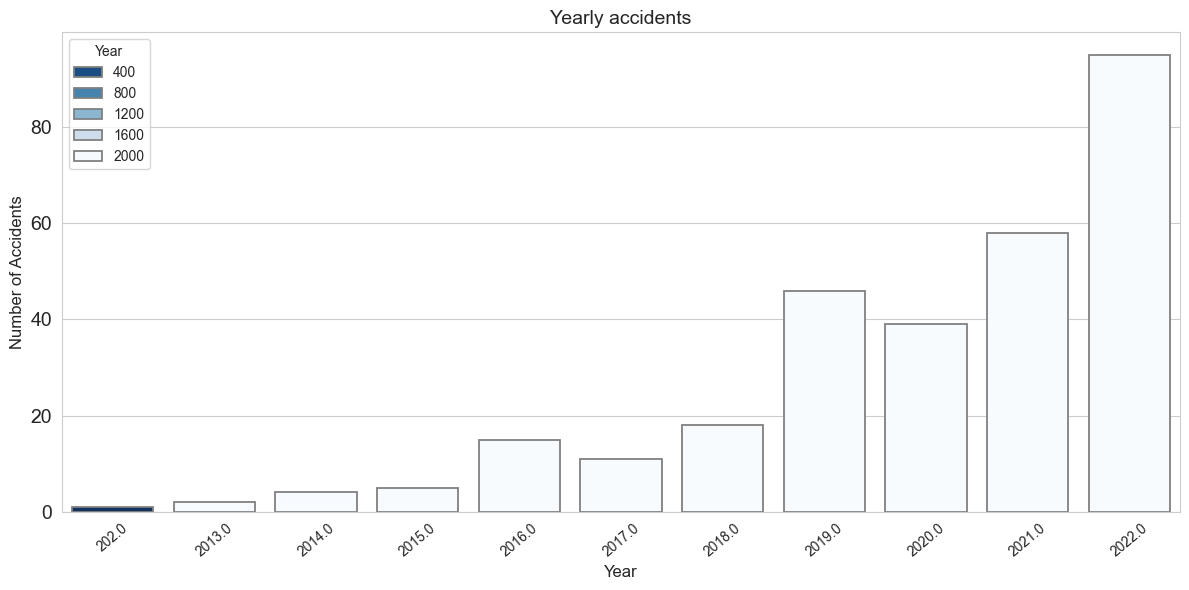

In [183]:
sns.set_style('whitegrid')

# Count yearly_accidents
yearly_accidents = tesla_df.groupby('Year').size()
print(yearly_accidents)

plt.figure(figsize=(12,6))
sns.barplot(x = yearly_accidents.index, y = yearly_accidents.values, hue = yearly_accidents.index,
            palette = 'Blues_r', edgecolor = 'grey', linewidth = 1.3)

plt.title('Yearly accidents', fontsize = 14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(rotation = 40)
plt.yticks(fontsize = 14)
plt.tight_layout()
plt.show()

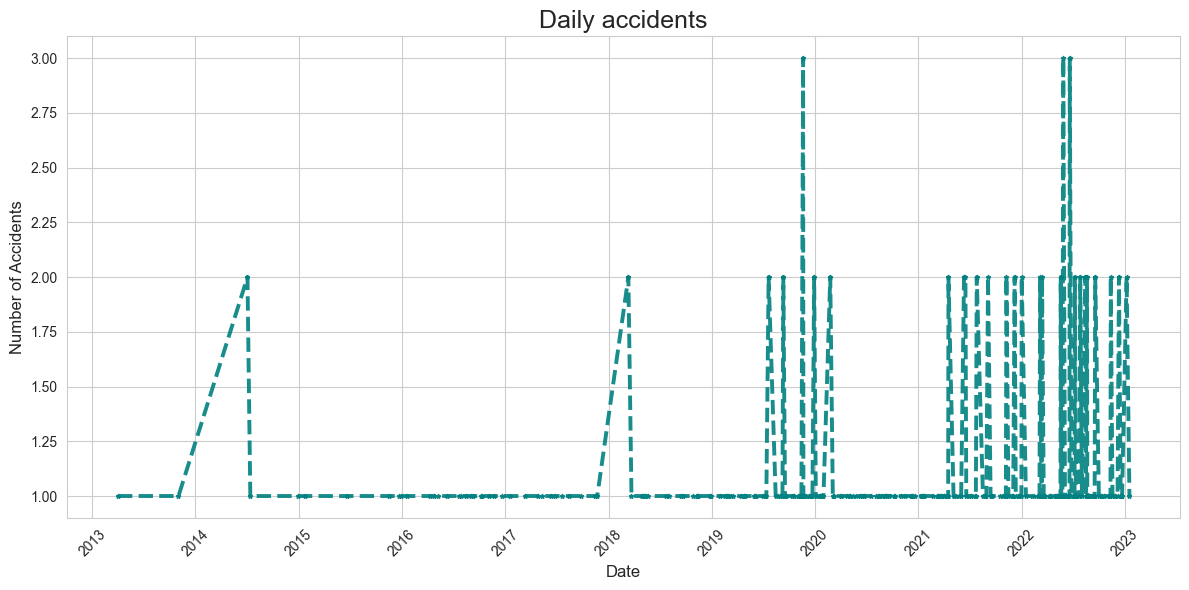

In [185]:
# Events per Date

daily_accidents = tesla_df.groupby('Date').size()

plt.figure(figsize = (12,6))
plt.plot(daily_accidents.index, daily_accidents.values, color = 'teal', linewidth = 2.8, marker = '*', markersize = 3.5, linestyle = '--', alpha = 0.9 )
plt.title('Daily accidents', fontsize = 18)
plt.xlabel('Date', fontsize = 12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

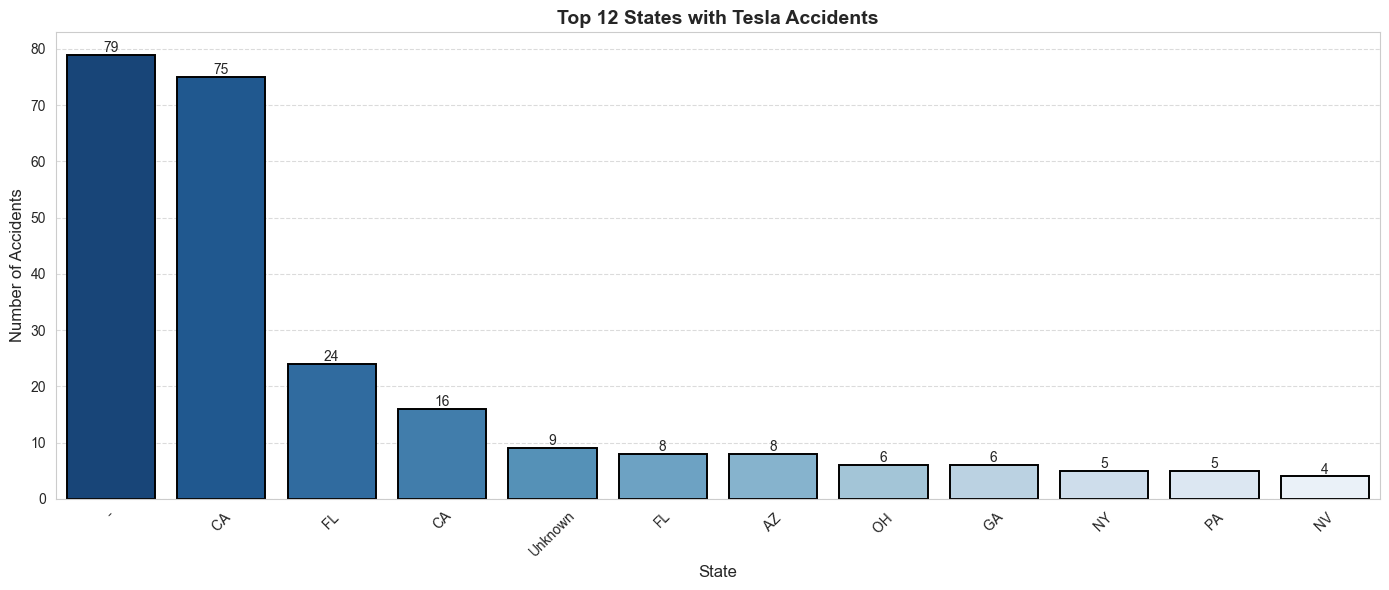

In [191]:
# Events per State (Top 12 states)

top_12_states = tesla_df['State'].value_counts().head(12)

sns.set_style("whitegrid")

plt.figure(figsize=(14,6))
sns.barplot(x = top_12_states.index, y = top_12_states.values,
             hue = top_12_states.index, palette = 'Blues_r', edgecolor = 'black', linewidth = 1.4)

# Label each bar with its value
for idx, count in enumerate(top_12_states.values):
    plt.text(idx, count + 0.5, str(count), ha='center', fontsize=10)

plt.title('Top 12 States with Tesla Accidents', fontsize = 14, fontweight ='bold')
plt.xlabel('State', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)

plt.tight_layout()
plt.show()

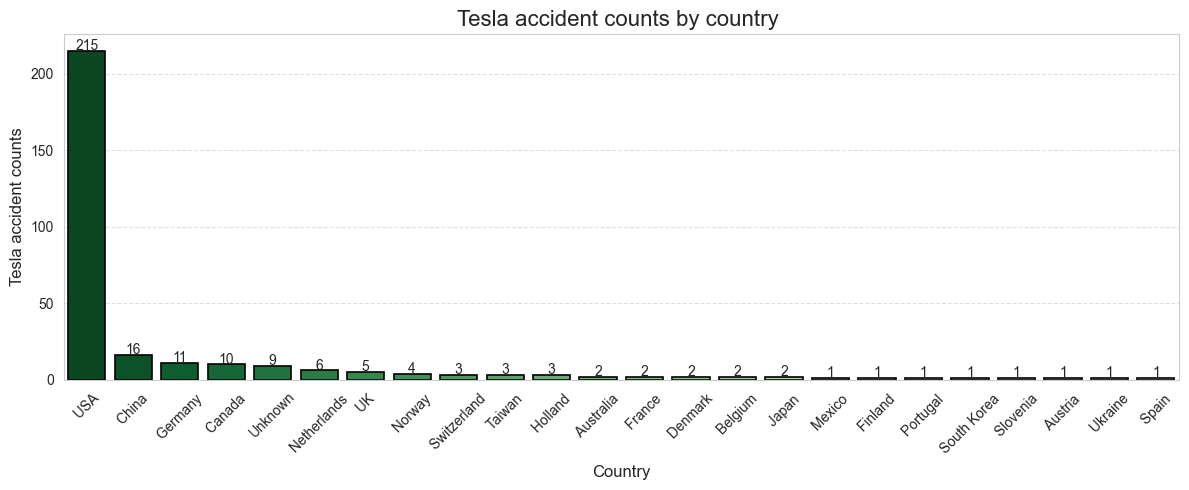

In [195]:
# Events per Country

accidents_by_country = tesla_df['Country'].value_counts()

sns.set_style("whitegrid")

plt.figure(figsize = (12,5))
sns.barplot(x = accidents_by_country.index, y = accidents_by_country.values, hue=accidents_by_country.index,
            palette = 'Greens_r', edgecolor = 'black', linewidth = 1.2)

#  Show values above each bar
for idx, count in enumerate(accidents_by_country.values):
    plt.text(idx, count + 0.5, str(count), ha = 'center', fontsize = 10)

plt.title('Tesla accident counts by country ', fontsize = 16)
plt.xlabel('Country', fontsize = 12)
plt.ylabel('Tesla accident counts', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.6)

plt.tight_layout()
plt.show()

## 2 (b) Analyze the different aspects of the death events. For example

#### Number of victims (Deaths) in each accident

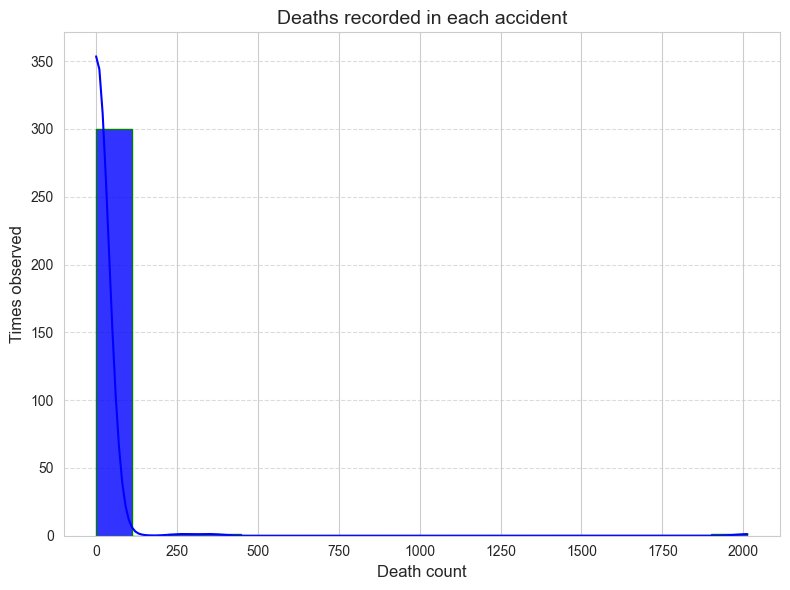

In [201]:
# a. Deaths recorded in each accident
sns.set_style("whitegrid")

plt.figure(figsize = (8,6))

sns.histplot(tesla_df['Deaths'], bins = 18, color = 'blue', edgecolor = 'green', linewidth = 1, kde = True, alpha = 0.8)
plt.title('Deaths recorded in each accident', fontsize = 14)
plt.xlabel('Death count', fontsize = 12)
plt.ylabel('Times observed', fontsize = 12)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)

plt.tight_layout()
plt.show()

#### How many times did tesla drivers die?

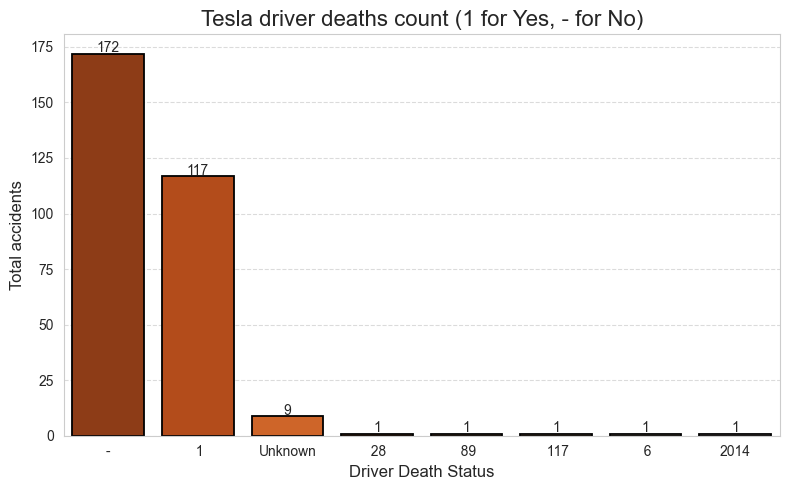

In [203]:
# Tesla driver deaths count

tesla_driver_deaths = tesla_df['Tesla driver'].value_counts()
sns.set_style('whitegrid')

plt.figure(figsize=(8,5))
sns.barplot(x = tesla_driver_deaths.index, y = tesla_driver_deaths.values, hue = tesla_driver_deaths.index,  palette = 'Oranges_r', edgecolor = 'black', linewidth = 1.3)

for idx, count in enumerate(tesla_driver_deaths.values):
    plt.text(idx, count + 0.5, str(count), ha='center', fontsize=10)

plt.title('Tesla driver deaths count (1 for Yes, - for No)', fontsize=16)
plt.xlabel('Driver Death Status', fontsize=12)
plt.ylabel('Total accidents', fontsize=12)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.tight_layout()
plt.show()

#### What is the proportion of events in which one or more occupants died?

In [314]:
# proportion of events in which one or more occupants died

tesla_df['tesla_occupant_fixed'] = tesla_df['Tesla occupant'].str.strip()
tesla_df['tesla_occupant_fixed'] = tesla_df['tesla_occupant_fixed'].replace('-', '0')
tesla_df['Tesla occupant_numeric'] = pd.to_numeric(tesla_df['tesla_occupant_fixed'], errors='coerce')
tesla_df['Tesla occupant_numeric'] = tesla_df['Tesla occupant_numeric'].fillna(0)
tesla_df['Tesla occupant_num'] = tesla_df['Tesla occupant_numeric'].astype(int)

occupant_deaths_fraction = (tesla_df['Tesla occupant_num'] > 0).mean()
print(f'Proportion of events with one or more Tesla occupant deaths: {occupant_deaths_fraction:.3f}')


Proportion of events with one or more Tesla occupant deaths: 0.158


#### What is the distribution of events in which the vehicle hit a cyclist or a pedestrian?

Different values in 'Cyclists/ Peds': <StringArray>
[' - ', '  1 ', '  2 ', 'Unknown', '  20 ', '  26 ', '  46 ', '  11 ', '2017']
Length: 9, dtype: str

0    -
1    -
2    -
3    -
4    1
Name: cyclists_peds_cleaned, dtype: str

0    0
1    0
2    0
3    0
4    1
Name: cyclists_peds_cleaned, dtype: str

  Cyclists/ Peds cyclists_peds_cleaned  cyclists_peds_numeric
0             -                      0                      0
1             -                      0                      0
2             -                      0                      0
3             -                      0                      0
4             1                      1                      1


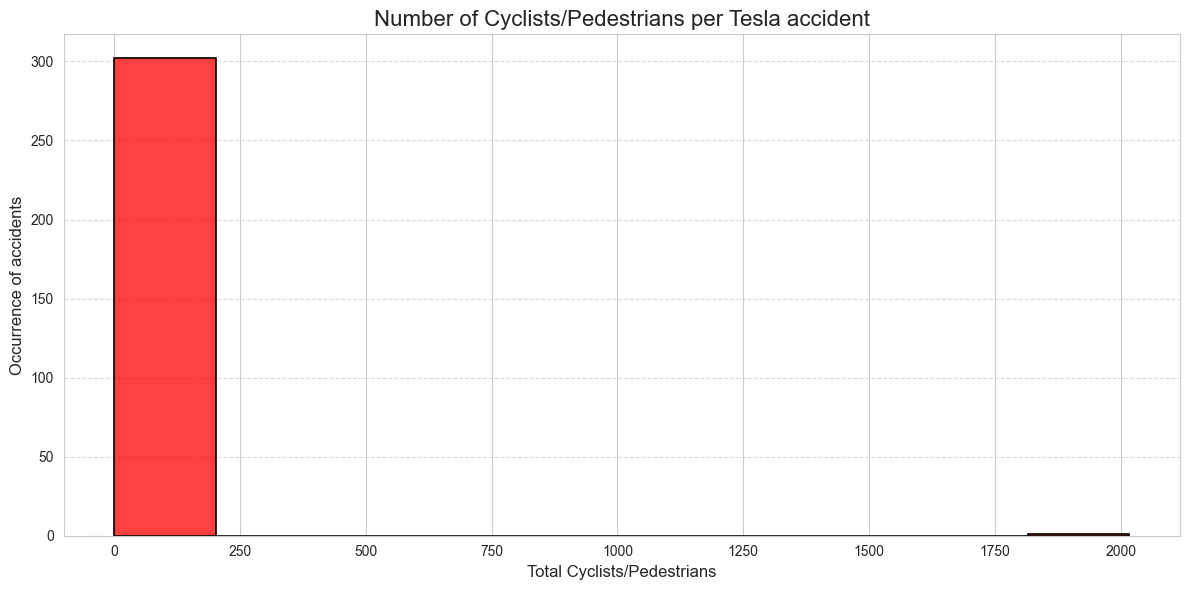

In [205]:
# d. Distribution of events with Cyclists or Pedestrians

print("Different values in 'Cyclists/ Peds':", tesla_df['Cyclists/ Peds'].unique())

print()

tesla_df['cyclists_peds_cleaned'] = tesla_df['Cyclists/ Peds'].str.strip()
print(tesla_df['cyclists_peds_cleaned'].head())

print()

tesla_df['cyclists_peds_cleaned'] = tesla_df['cyclists_peds_cleaned'].replace('-', '0')
print(tesla_df['cyclists_peds_cleaned'].head())

print()

tesla_df['cyclists_peds_numeric'] = pd.to_numeric(tesla_df['cyclists_peds_cleaned'], errors='coerce')
tesla_df['cyclists_peds_numeric'] = tesla_df['cyclists_peds_numeric'].fillna(0).astype(int)
print(tesla_df[['Cyclists/ Peds', 'cyclists_peds_cleaned', 'cyclists_peds_numeric']].head())


plt.figure(figsize = (12,6))
sns.histplot(tesla_df['cyclists_peds_numeric'], bins = 10, color = 'red', edgecolor = 'black', linewidth=1.2)

plt.title('Number of Cyclists/Pedestrians per Tesla accident', fontsize=16)
plt.xlabel('Total Cyclists/Pedestrians', fontsize = 12)
plt.ylabel('Occurrence of accidents', fontsize = 12)
plt.grid(axis = 'y', linestyle = '--', alpha=0.7)
plt.tight_layout()
plt.show()

#### How many times did the accident involve the death of an occupant or driver of a Tesla along with a cyclist or pedestrian

In [207]:
# Accidents involving Tesla occupant or driver death along with Cyclist or Pedestrian

tesla_df['Tesla_occupant_cleaned'] = tesla_df['Tesla occupant'].str.strip().replace('-', '0')
tesla_df['Tesla_occupant_numeric'] = pd.to_numeric(tesla_df['Tesla_occupant_cleaned'], errors='coerce').fillna(0).astype(int)

tesla_df['Cyclists_peds_cleaned'] = tesla_df['Cyclists/ Peds'].str.strip().replace('-', '0')
tesla_df['Cyclists_peds_numeric'] = pd.to_numeric(tesla_df['Cyclists_peds_cleaned'], errors='coerce').fillna(0).astype(int)

occupant_cyclist_accidents = tesla_df[(tesla_df['Tesla_occupant_numeric'] > 0) & (tesla_df['Cyclists_peds_numeric'] > 0)]

# Total number of matching accidents
accidents_with_occupant_and_pedestrian_count = len(occupant_cyclist_accidents)
print(f'Count of accidents with occupant death and cyclist/pedestrian involved: {accidents_with_occupant_and_pedestrian_count}')

occupant_cyclist_accidents[['Date', 'State', 'Tesla occupant', 'Cyclists/ Peds', 'Deaths']].head()

Count of accidents with occupant death and cyclist/pedestrian involved: 6


,Date,State,Tesla occupant,Cyclists/ Peds,Deaths
116,2021-09-04,FL,1,1,2.0
294,NaT,Unknown,7,20,92.0
295,NaT,Unknown,41,26,261.0
296,NaT,Unknown,48,46,353.0
300,NaT,Unknown,5,11,3.0


#### What is the frequency of Tesla colliding with other vehicles?

Unique values in 'Other_vehicle_numeric': [   0    1    2    3    4   29  101  130   16 2016]


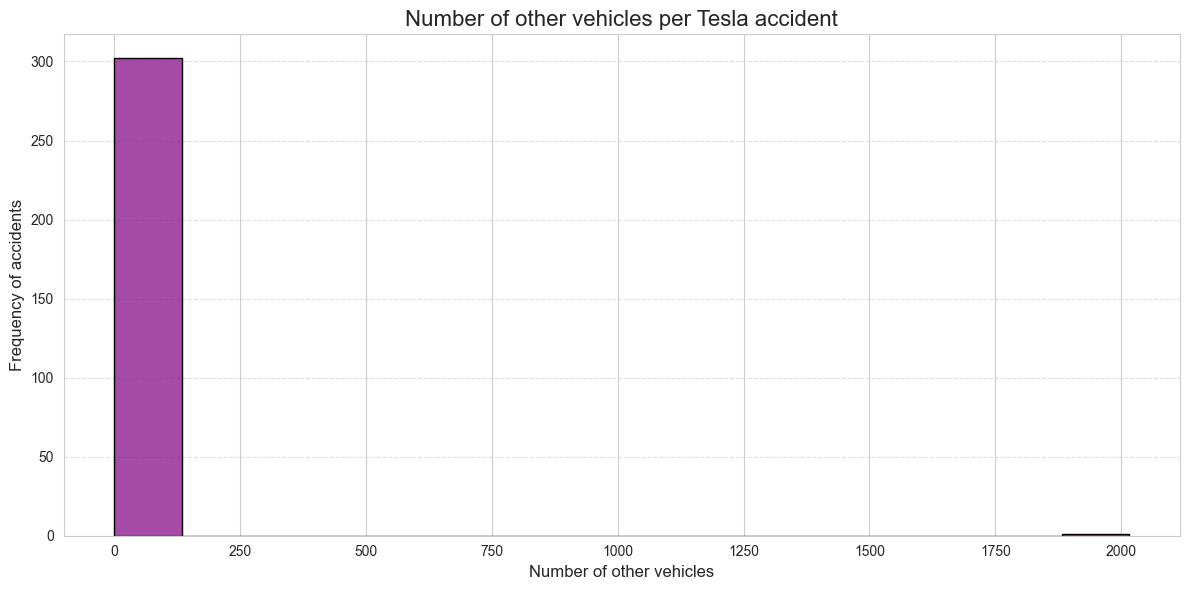

In [209]:
# Frequency of Tesla accidents involving other vehicles

tesla_df['Other_vehicle_cleaned'] = tesla_df['Other vehicle'].str.strip().replace('-', '0')
tesla_df['Other_vehicle_numeric'] = pd.to_numeric(tesla_df['Other_vehicle_cleaned'], errors='coerce').fillna(0).astype(int)

# Step 2: Overview of unique values
print("Unique values in 'Other_vehicle_numeric':", tesla_df['Other_vehicle_numeric'].unique())

plt.figure(figsize = (12,6))
sns.histplot(tesla_df['Other_vehicle_numeric'], bins = 15, color = 'purple', edgecolor = 'black', linewidth = 1, alpha = 0.7
)
plt.title('Number of other vehicles per Tesla accident', fontsize = 16)
plt.xlabel('Number of other vehicles', fontsize = 12)
plt.ylabel('Frequency of accidents', fontsize = 12)
plt.grid(axis = 'y', linestyle = '--', alpha=0.6)
plt.tight_layout()
plt.show()

### Study the event distribution across models

Top 11 Tesla Models involved in accidents:
 Model
 -         181
 S          45
  3         39
 X          17
 Y          10
Unknown      7
  1          1
  2          1
  50         1
2019         1
Name: count, dtype: int64


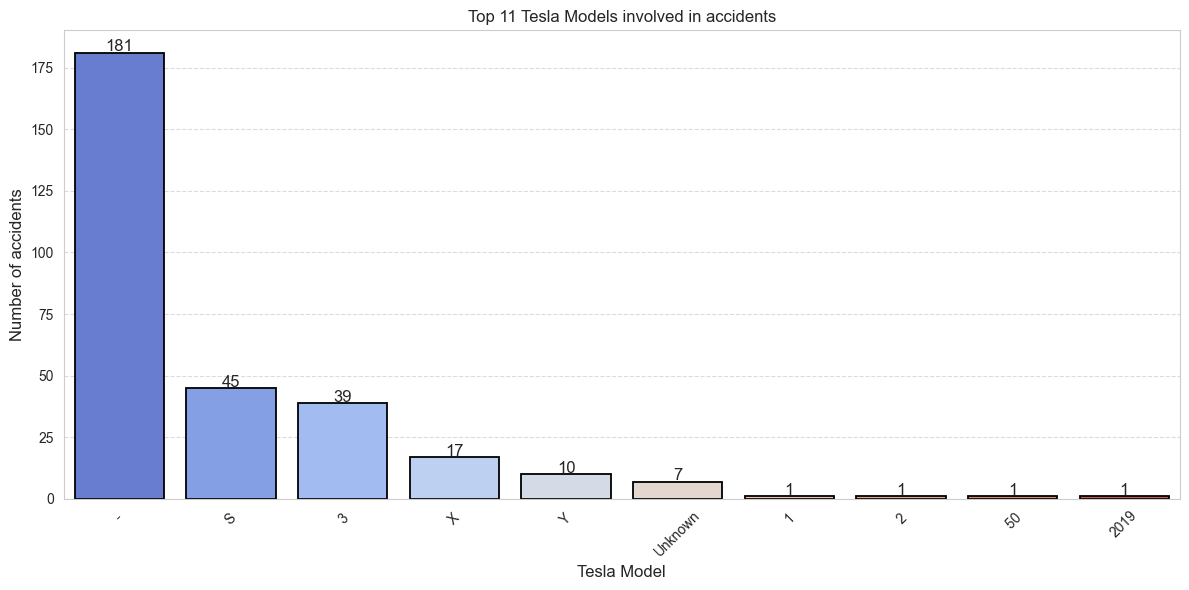

In [213]:
# Top 10 Tesla Models Involved in Accidents

top_tesla_models = tesla_df['Model'].value_counts().head(11)
print("Top 11 Tesla Models involved in accidents:\n", top_tesla_models)

plt.figure(figsize=(12,6))
sns.barplot(x = top_tesla_models.index, y = top_tesla_models.values,  hue = top_tesla_models.index, palette = 'coolwarm', edgecolor = 'black', linewidth = 1.3)

for idx, count in enumerate(top_tesla_models.values):
    plt.text(idx, count + 0.5, str(count), ha = 'center', fontsize = 12)

plt.title('Top 11 Tesla Models involved in accidents', fontsize = 12)
plt.xlabel('Tesla Model', fontsize = 12)
plt.ylabel('Number of accidents', fontsize = 12)
plt.xticks(rotation = 45)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)

plt.tight_layout()
plt.show()

### Check the distribution of verified Tesla autopilot deaths

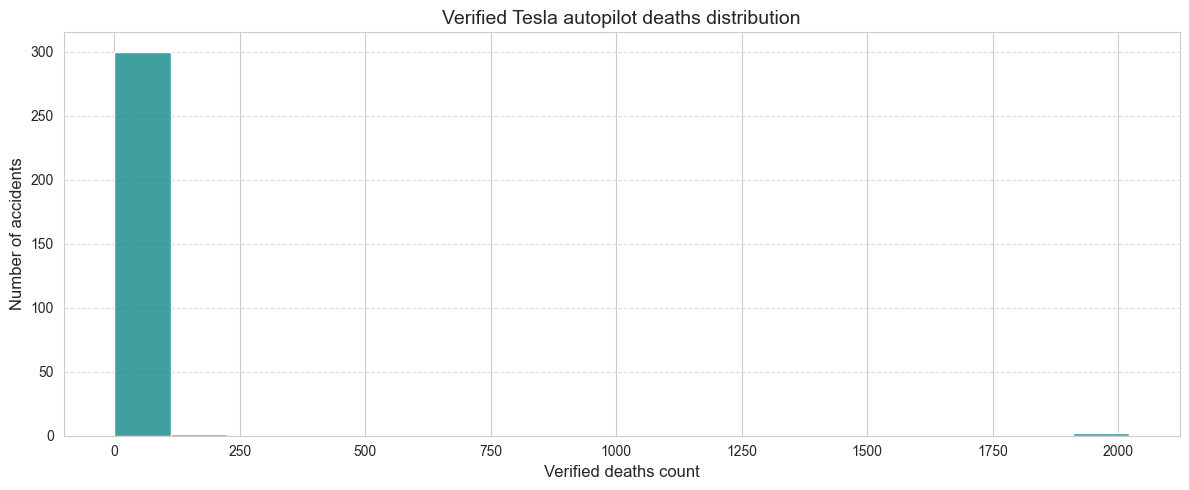

In [215]:
# Distribution of Verified Tesla Autopilot Deaths

tesla_df['Verified_Tesla_Autopilot_Deaths_numeric'] = pd.to_numeric(
    tesla_df['Verified Tesla Autopilot Deaths'].astype(str).str.strip().replace('-', '0'), errors = 'coerce').fillna(0).astype(int)

plt.figure(figsize = (12,5))
sns.histplot(tesla_df['Verified_Tesla_Autopilot_Deaths_numeric'], bins = 18, color = 'teal', kde = False)

plt.title('Verified Tesla autopilot deaths distribution', fontsize = 14)
plt.xlabel('Verified deaths count', fontsize=12)
plt.ylabel('Number of accidents', fontsize=12)

plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.tight_layout()
plt.show()